In [1]:
!pip install yfinance -q


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [3]:
ticker = "AAPL"   # change to any company ticker
df = yf.download(ticker, start="2014-01-01", end="2024-12-31")
df.reset_index(inplace=True)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [c[0] if c[0] else c[1] for c in df.columns]
print(df.shape)
df.head()


/tmp/ipykernel_817/1674539099.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2014-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

(2767, 6)


,Date,Close,High,Low,Open,Volume
0,2014-01-02,17.124887,17.245632,17.090522,17.203836,234684800
1,2014-01-03,16.748726,17.142536,16.731697,17.116531,392467600
2,2014-01-06,16.840052,16.928906,16.520235,16.639431,412610800
3,2014-01-07,16.719620,16.902902,16.653985,16.852128,317209200
4,2014-01-08,16.825500,16.890515,16.677822,16.681535,258529600


In [16]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/17_BHtSzptN4IxyC77kYEjXs9pS8tXjevHstmdSS06pw/edit#gid=0


In [4]:
print(df.info())
print(df.isna().sum())
print("Duplicates:", df.duplicated().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2767 entries, 0 to 2766
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2767 non-null   datetime64[ns]
 1   Close   2767 non-null   float64       
 2   High    2767 non-null   float64       
 3   Low     2767 non-null   float64       
 4   Open    2767 non-null   float64       
 5   Volume  2767 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 129.8 KB
None
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Duplicates: 0


,Date,Close,High,Low,Open,Volume
count,2767,2767.000000,2767.000000,2767.000000,2767.000000,2.767000e+03
mean,2019-07-01 06:15:13.335742720,86.940731,87.781948,86.005300,86.860306,1.294561e+08
min,2014-01-02 00:00:00,15.473176,15.527347,15.280287,15.330752,2.323470e+07
25%,2016-09-29 12:00:00,28.046371,28.251313,27.831439,28.032461,7.427880e+07
50%,2019-07-02 00:00:00,51.109295,51.927396,50.740460,51.265365,1.061813e+08
75%,2022-03-29 12:00:00,145.783524,147.320112,144.318336,145.562318,1.614519e+08
max,2024-12-30 00:00:00,257.375549,258.448710,255.994390,256.550832,1.065523e+09
std,NaN,65.707545,66.310343,65.010282,65.626202,8.383306e+07


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
for col in ["Open","High","Low","Close","Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.drop_duplicates().sort_values("Date").reset_index(drop=True)

df[["Open","High","Low","Close"]] = df[["Open","High","Low","Close"]].interpolate(method="linear")
df["Volume"] = df["Volume"].fillna(df["Volume"].median())
df.loc[df["Volume"] < 0, "Volume"] = df["Volume"].median()

for col in ["Open","High","Low","Close"]:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df[col] = df[col].clip(lower, upper)

print("Cleaned shape:", df.shape)
print(df.isna().sum())


Cleaned shape: (2767, 6)
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [6]:
df["Daily_Return"]   = df["Close"].pct_change()
df["MA_7"]           = df["Close"].rolling(7).mean()
df["MA_30"]          = df["Close"].rolling(30).mean()
df["MA_200"]         = df["Close"].rolling(200).mean()
df["Volatility_30"]  = df["Daily_Return"].rolling(30).std()
df["Year"]    = df["Date"].dt.year
df["Month"]   = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()

df.to_csv(f"{ticker}_cleaned.csv", index=False)

In [7]:
print(df[["Open","High","Low","Close","Volume","Daily_Return"]].describe())

# Yearly average closing price
print(df.groupby("Year")["Close"].mean())

              Open         High          Low        Close        Volume  \
count  2767.000000  2767.000000  2767.000000  2767.000000  2.767000e+03   
mean     86.860306    87.781948    86.005300    86.940731  1.294561e+08   
std      65.626202    66.310343    65.010282    65.707545  8.383306e+07   
min      15.330752    15.527347    15.280287    15.473176  2.323470e+07   
25%      28.032461    28.251313    27.831439    28.046371  7.427880e+07   
50%      51.265365    51.927396    50.740460    51.109295  1.061813e+08   
75%     145.562318   147.320112   144.318336   145.783524  1.614519e+08   
max     256.550832   258.448710   255.994390   257.375549  1.065523e+09   

       Daily_Return  
count   2766.000000  
mean       0.001125  
std        0.017582  
min       -0.128647  
25%       -0.007012  
50%        0.001000  
75%        0.010116  
max        0.119808  
Year
2014     20.248736
2015     26.794900
2016     23.833444
2017     34.949198
2018     44.555957
2019     49.856191
2020   

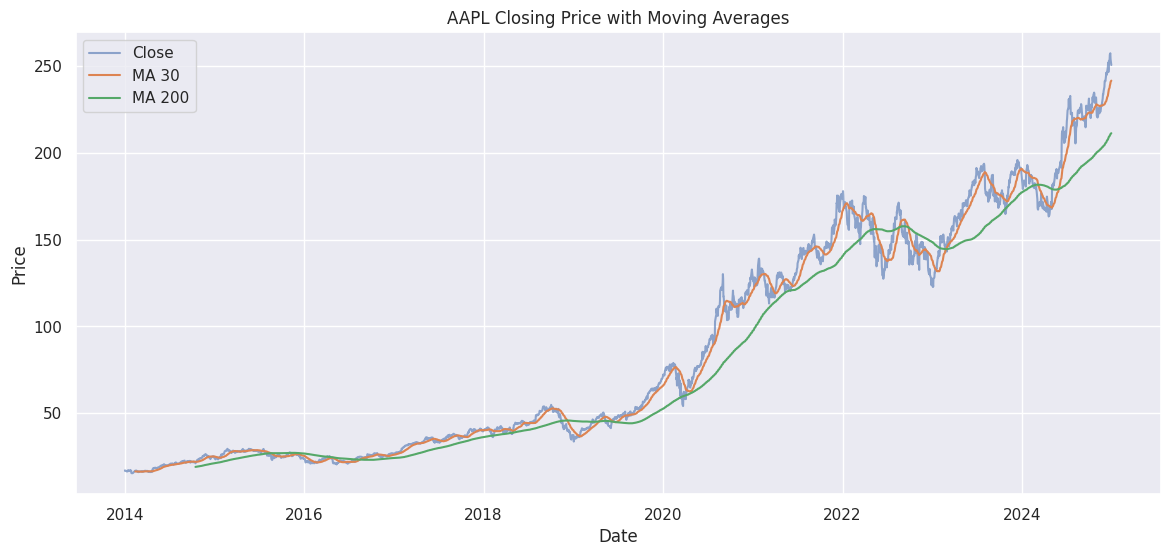

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"], label="Close", alpha=0.6)
plt.plot(df["Date"], df["MA_30"], label="MA 30")
plt.plot(df["Date"], df["MA_200"], label="MA 200")
plt.title(f"{ticker} Closing Price with Moving Averages")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend()
plt.show()

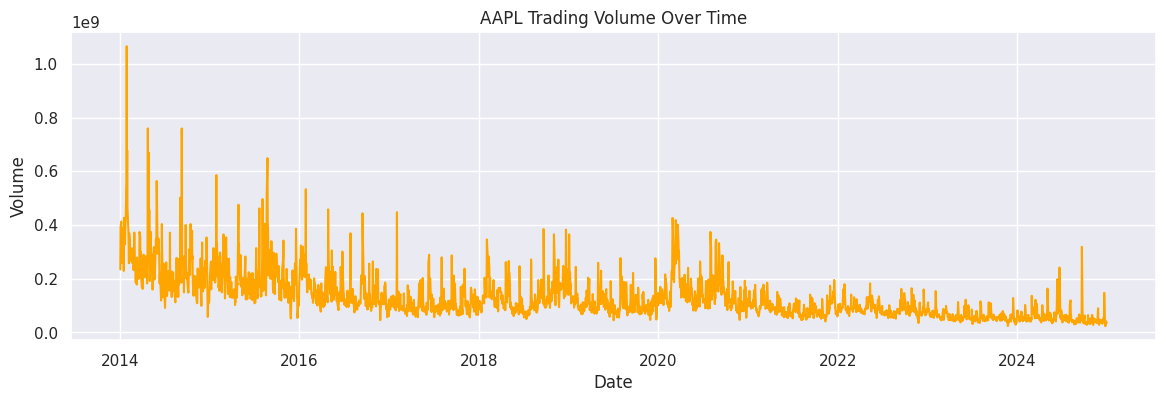

In [9]:
plt.figure(figsize=(14,4))
plt.plot(df["Date"], df["Volume"], color="orange")
plt.title(f"{ticker} Trading Volume Over Time")
plt.xlabel("Date"); plt.ylabel("Volume")
plt.show()

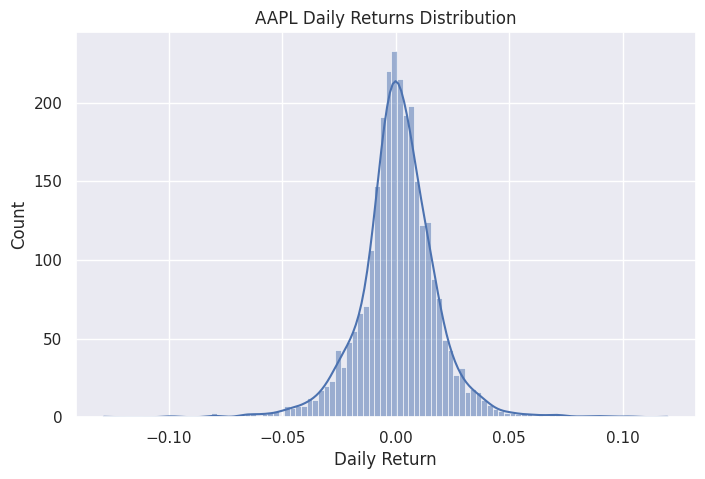

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Daily_Return"].dropna(), bins=100, kde=True)
plt.title(f"{ticker} Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.show()

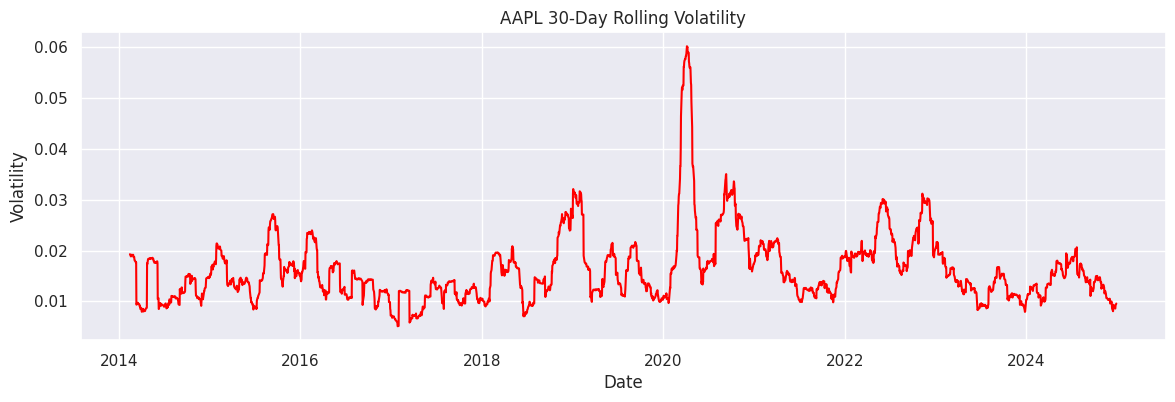

In [11]:
plt.figure(figsize=(14,4))
plt.plot(df["Date"], df["Volatility_30"], color="red")
plt.title(f"{ticker} 30-Day Rolling Volatility")
plt.xlabel("Date"); plt.ylabel("Volatility")
plt.show()

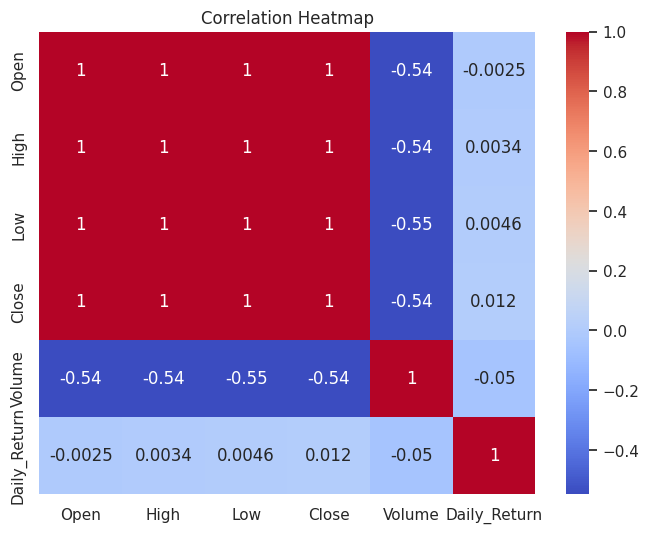

In [12]:
plt.figure(figsize=(8,6))
corr = df[["Open","High","Low","Close","Volume","Daily_Return"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

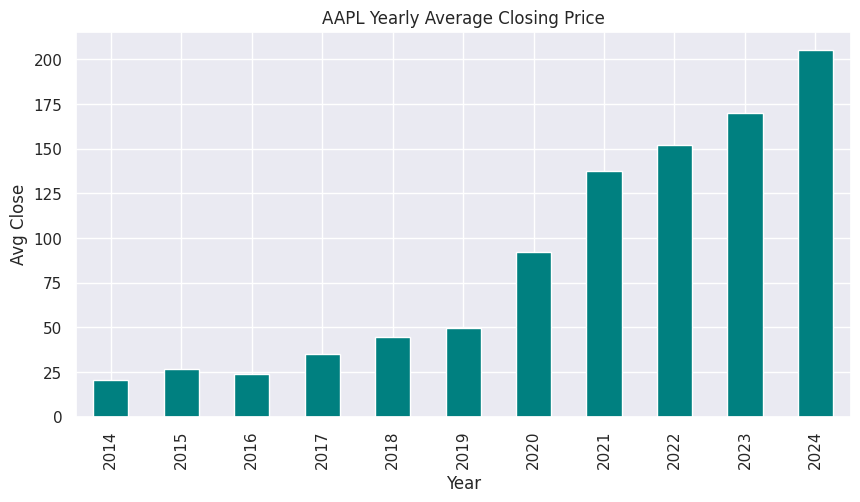

In [13]:
yearly_avg = df.groupby("Year")["Close"].mean()
plt.figure(figsize=(10,5))
yearly_avg.plot(kind="bar", color="teal")
plt.title(f"{ticker} Yearly Average Closing Price")
plt.xlabel("Year"); plt.ylabel("Avg Close")
plt.show()

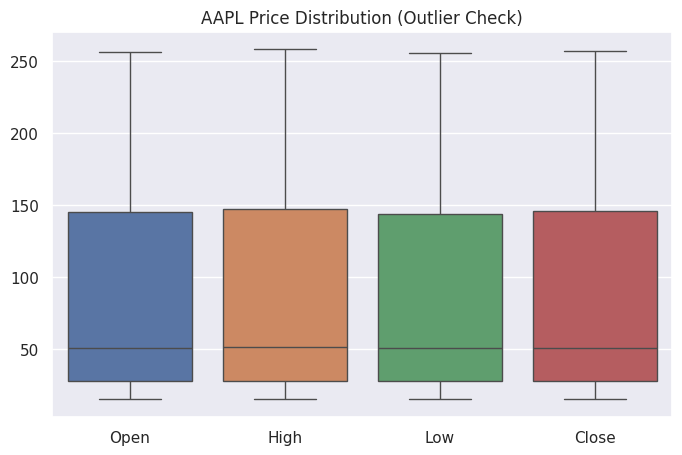

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["Open","High","Low","Close"]])
plt.title(f"{ticker} Price Distribution (Outlier Check)")
plt.show()

In [15]:
from google.colab import files
files.download(f"{ticker}_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>